# Analisis Dataset Ventas de autos 

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


## Revisar


In [ ]:
df = pd.read_csv("car_prices.csv")

In [56]:
#Revisar
df.info()
df.head()
#print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [57]:
df.describe()

,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


## Limpiar

In [58]:
#Limpio todas las filas que posean algun nulo 
df.dropna(inplace=True)

In [59]:
#Convertir los tipos de datos a los tipos correctos, optimizando el uso de memoria
df['make'] = df['make'].astype('string')
df['model'] = df['model'].astype('string')
df['trim'] = df['trim'].astype('string')
df['body'] = df['body'].astype('string')
df['transmission'] = df['transmission'].astype('string')
df['vin'] = df['vin'].astype('string')
df['state'] = df['state'].astype('string')
df['condition'] = df['condition'].astype('int64')
df['odometer'] = df['odometer'].astype('int64')
df['color'] = df['color'].astype('string')
df['interior'] = df['interior'].astype('string')
df['seller'] = df['seller'].astype('string')
df['mmr'] = df['mmr'].astype('int64')
df['sellingprice'] = df['sellingprice'].astype('int64')
df['saledate'] = pd.to_datetime(df['saledate'], utc=True, errors='coerce')
df['saledate'] = df['saledate'].dt.tz_convert('UTC').dt.tz_localize(None)

C:\Users\admin\AppData\Local\Temp\ipykernel_10704\1324384139.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['saledate'] = pd.to_datetime(df['saledate'], utc=True, errors='coerce')


In [60]:
#Renombrar los encabezados de la columna al español para comprenderlo mejor
df.rename(columns={
    'year': 'año',
    'make': 'marca',
    'model': 'modelo',
    'trim': 'version',
    'body': 'carroceria',
    'transmission': 'transmision',
    'vin': 'vin',
    'state': 'estado',
    'condition': 'condicion',
    'odometer': 'odometro',
    'color': 'color_exterior',
    'interior': 'color_interior',
    'seller': 'vendedor',
    'mmr': 'valor_estimado_mmr',
    'sellingprice': 'precio_venta',
    'saledate': 'fecha_venta'
}, inplace=True)

In [61]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 472325 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   año                 472325 non-null  int64         
 1   marca               472325 non-null  string        
 2   modelo              472325 non-null  string        
 3   version             472325 non-null  string        
 4   carroceria          472325 non-null  string        
 5   transmision         472325 non-null  string        
 6   vin                 472325 non-null  string        
 7   estado              472325 non-null  string        
 8   condicion           472325 non-null  int64         
 9   odometro            472325 non-null  int64         
 10  color_exterior      472325 non-null  string        
 11  color_interior      472325 non-null  string        
 12  vendedor            472325 non-null  string        
 13  valor_estimado_mmr  472325 non-nul

,año,marca,modelo,version,carroceria,transmision,vin,estado,condicion,odometro,color_exterior,color_interior,vendedor,valor_estimado_mmr,precio_venta,fecha_venta
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5,16639,white,black,kia motors america inc,20500,21500,2014-12-16 04:30:00
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5,9393,white,beige,kia motors america inc,20800,21500,2014-12-16 04:30:00
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45,1331,gray,black,financial services remarketing (lease),31900,30000,2015-01-14 20:30:00
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41,14282,white,black,volvo na rep/world omni,27500,27750,2015-01-28 20:30:00
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43,2641,gray,black,financial services remarketing (lease),66000,67000,2014-12-18 04:30:00


## Visualizar Tablas

In [64]:
df.head()

,año,marca,modelo,version,carroceria,transmision,vin,estado,condicion,odometro,color_exterior,color_interior,vendedor,valor_estimado_mmr,precio_venta,fecha_venta
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5,16639,white,black,kia motors america inc,20500,21500,2014-12-16 04:30:00
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5,9393,white,beige,kia motors america inc,20800,21500,2014-12-16 04:30:00
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45,1331,gray,black,financial services remarketing (lease),31900,30000,2015-01-14 20:30:00
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41,14282,white,black,volvo na rep/world omni,27500,27750,2015-01-28 20:30:00
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43,2641,gray,black,financial services remarketing (lease),66000,67000,2014-12-18 04:30:00


In [73]:
#Comparativa del promedio de precios con la mediana
media = df.groupby('marca')['precio_venta'].mean().round()
mediana = df.groupby('marca')['precio_venta'].median().round()

resultado = pd.DataFrame({
    'media': media,
    'mediana': mediana
}).sort_values(by='media', ascending=False)

resultado

,media,mediana
marca,,
Rolls-Royce,153456.0,149400.0
Ferrari,128853.0,124000.0
Lamborghini,111500.0,110000.0
Bentley,72713.0,62000.0
Tesla,67054.0,66500.0
Aston Martin,55500.0,51000.0
Fisker,46461.0,46000.0
Maserati,43730.0,40250.0
Lotus,40800.0,40800.0


In [74]:
df.groupby('modelo')['odometro'].mean().round(2).sort_values(ascending=False)

modelo
Paseo             338382.00
Windstar Cargo    295231.00
Pickup            234806.29
400-Class         225623.00
LX 450            210052.50
                    ...    
RC F                3503.60
GLA-Class           3408.00
RC 350              2875.00
Q3                  1404.00
i8                  1056.11
Name: odometro, Length: 768, dtype: float64

In [94]:
df.groupby(['marca', 'modelo']).size().sort_values(ascending=False).head(10).reset_index(name='cantidad')


,marca,modelo,cantidad
0,Nissan,Altima,16346
1,Ford,Fusion,12116
2,Ford,F-150,11950
3,Toyota,Camry,10986
4,Ford,Escape,10656
5,Ford,Focus,9547
6,Honda,Accord,8528
7,Chevrolet,Impala,7500
8,BMW,3 Series,7132
9,Honda,Civic,7068


In [93]:
df.groupby(['marca', 'modelo', 'año']).size().sort_values(ascending=False).head(10).reset_index(name='cantidad')

,marca,modelo,año,cantidad
0,Nissan,Altima,2012,7090
1,Nissan,Altima,2013,4234
2,Ford,Fusion,2012,3858
3,Ford,Escape,2013,3758
4,Ford,Fusion,2013,3415
5,Ford,Focus,2013,3173
6,Honda,Accord,2012,3047
7,Hyundai,Elantra,2013,2840
8,Infiniti,G Sedan,2013,2807
9,Toyota,Camry,2012,2762


In [96]:
df.groupby('año')['precio_venta'].mean().sort_index(ascending=False)

año
2015    26168.987991
2014    19902.622748
2013    17319.476100
2012    16441.895022
2011    15690.067973
2010    12254.805271
2009    10227.297177
2008     9458.500056
2007     7861.239853
2006     5993.042809
2005     4881.957889
2004     4317.718732
2003     3395.425829
2002     2662.820746
2001     2161.770428
2000     1783.164575
1999     1520.473731
1998     1262.233607
1997     1081.333973
1996      922.864769
1995      875.931677
1994      856.468531
1993      777.362205
1992      874.742268
1991      994.607843
1990     1429.545455
Name: precio_venta, dtype: float64

## Visualizar Graficos

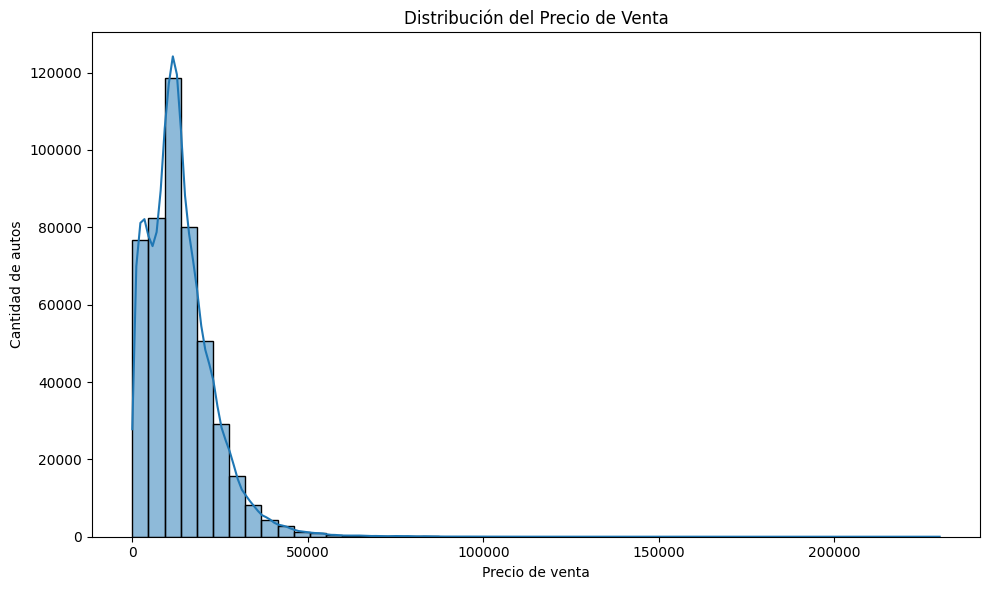

In [98]:
plt.figure(figsize=(10,6))
sns.histplot(df['precio_venta'], bins=50, kde=True)
plt.title('Distribución del Precio de Venta')
plt.xlabel('Precio de venta')
plt.ylabel('Cantidad de autos')
plt.tight_layout()
plt.show()

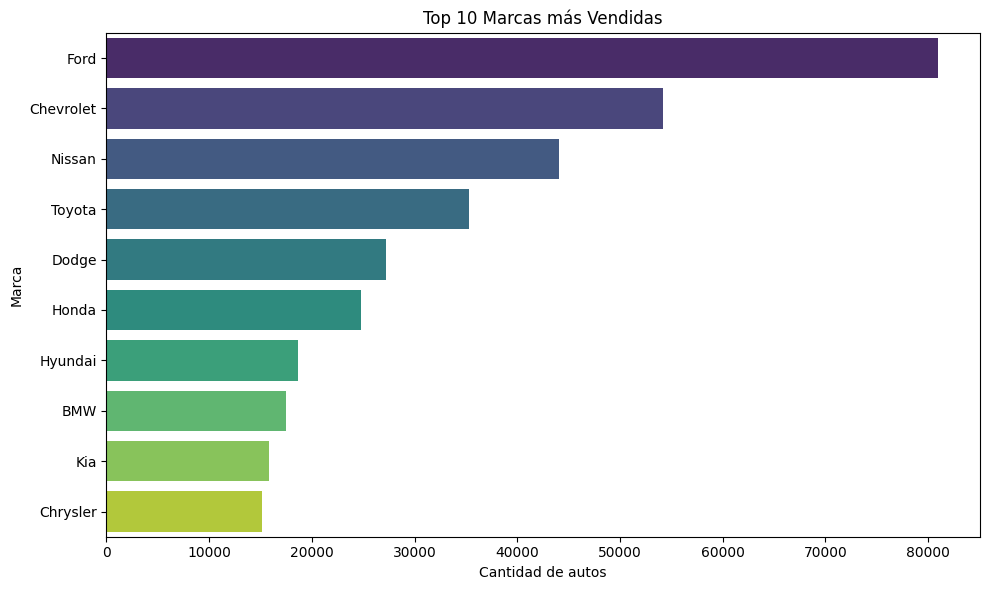

In [106]:
top_marcas_df = df['marca'].value_counts().head(10).reset_index()
top_marcas_df.columns = ['marca', 'cantidad']

plt.figure(figsize=(10,6))
sns.barplot(data=top_marcas_df, x='cantidad', y='marca', hue='marca', palette='viridis', legend=False)
plt.title('Top 10 Marcas más Vendidas')
plt.xlabel('Cantidad de autos')
plt.ylabel('Marca')
plt.tight_layout()
plt.show()

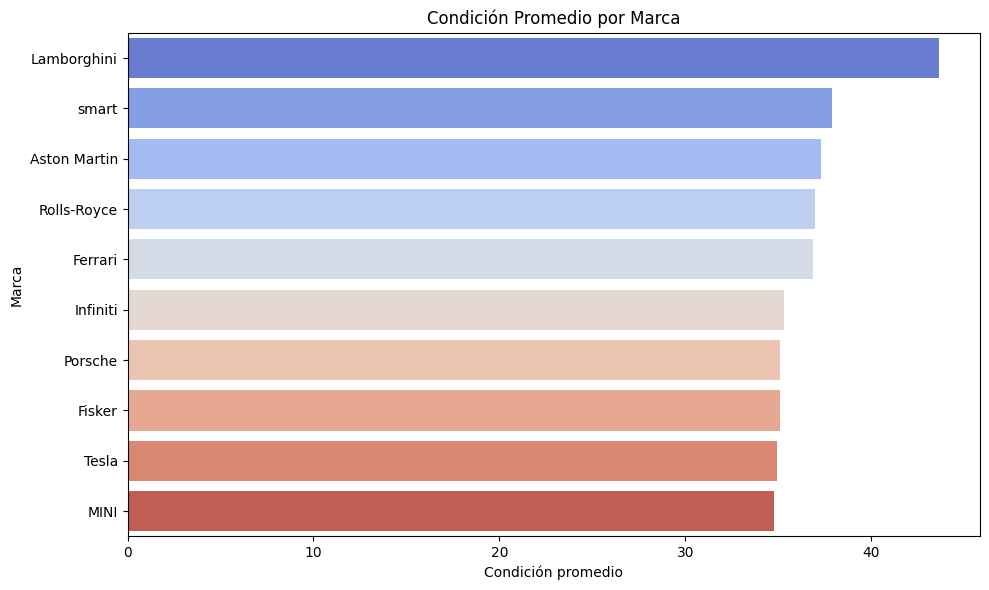

In [107]:
condicion_marca = df.groupby('marca')['condicion'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=condicion_marca, x='condicion', y='marca', hue='marca', palette='coolwarm', legend=False)
plt.title('Condición Promedio por Marca')
plt.xlabel('Condición promedio')
plt.ylabel('Marca')
plt.tight_layout()
plt.show()

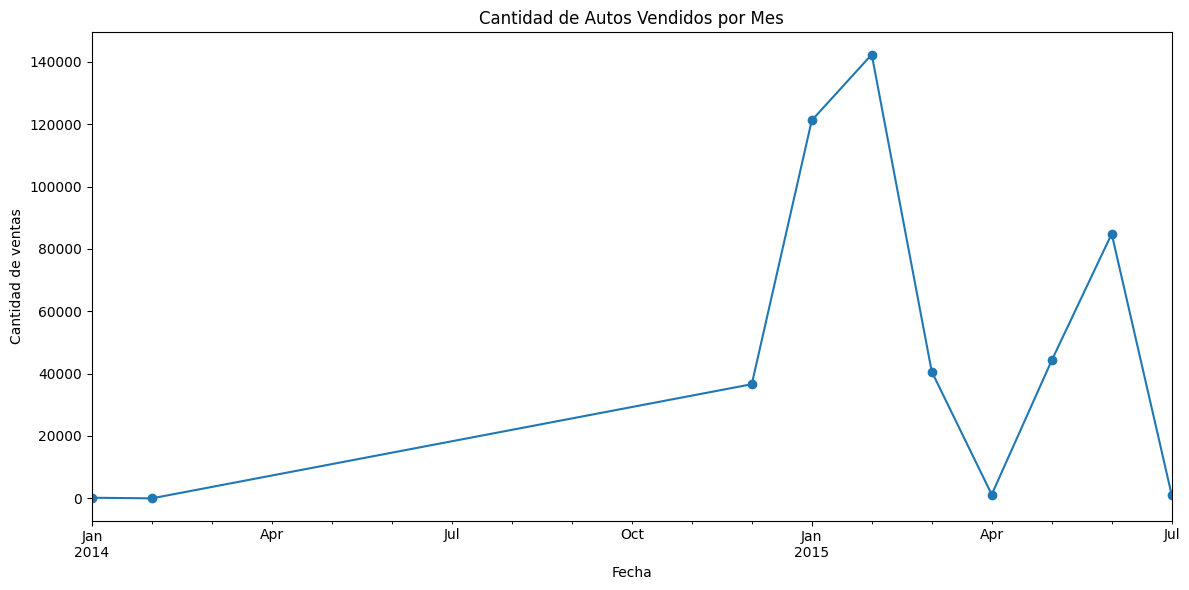

In [108]:
df['fecha_venta'] = pd.to_datetime(df['fecha_venta'], errors='coerce')

ventas_por_fecha = df.groupby(df['fecha_venta'].dt.to_period('M')).size()

ventas_por_fecha.plot(kind='line', figsize=(12,6), marker='o')
plt.title('Cantidad de Autos Vendidos por Mes')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de ventas')
plt.tight_layout()
plt.show()

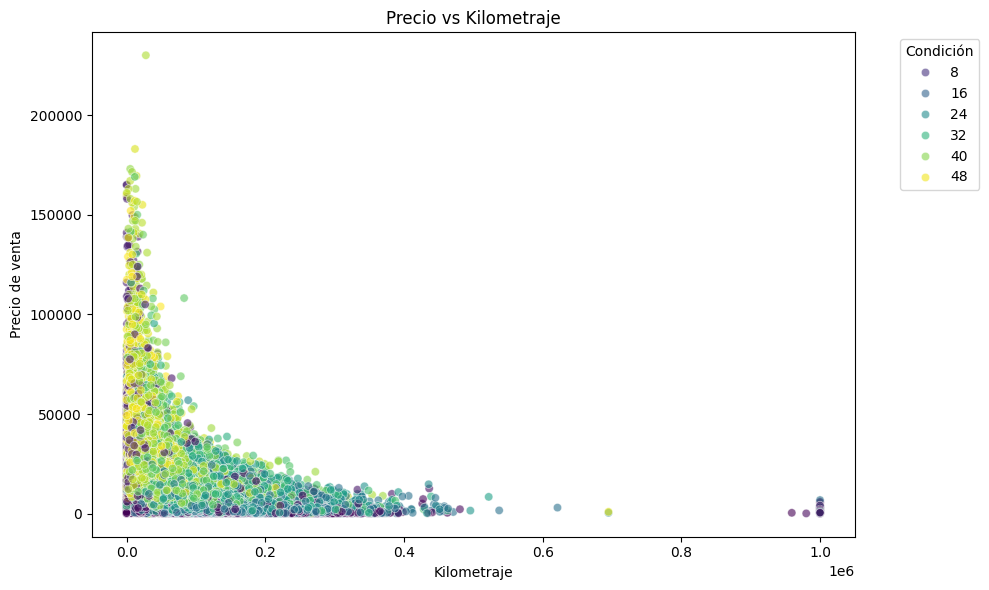

In [110]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='odometro', y='precio_venta', hue='condicion', alpha=0.6, palette='viridis')
plt.title('Precio vs Kilometraje')
plt.xlabel('Kilometraje')
plt.ylabel('Precio de venta')
plt.legend(title='Condición', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()